In [15]:
import os
import rioxarray
import rasterio
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from matplotlib.patches import Polygon
from IPython.display import Image, display
from sklearn.decomposition import PCA
from pyproj import Transformer
from pathlib import Path
from shapely.geometry import box
from pathlib import Path
from matplotlib.patches import Rectangle

In [16]:
STUDY_REGION = "Sulu Sea"

DATA_DIR = Path(f"./SWOT_IW_Labeled_Dataset/{STUDY_REGION}/")
DATA_DIR_OTHER = Path(f"./SWOT_IW_Dataset/{STUDY_REGION}/")

FILE_NAME = "SWOT_L2_LR_SSH_Expert_010_131_20240129T154827_20240129T163907_PIC0_01"
PERCENTAILE = 60
CMAP = "turbo"

In [17]:
nc_files = sorted(DATA_DIR.glob(f"data/{FILE_NAME}.nc"))
obb_label = sorted(DATA_DIR.glob(f"obb_labels/{FILE_NAME}.txt"))
bb_label = sorted(DATA_DIR.glob(f"bb_labels/{FILE_NAME}.txt"))

ds = xr.open_mfdataset(
                nc_files,
                combine="nested",
                decode_timedelta=True,
                compat='no_conflicts',
                engine='h5netcdf',
                parallel=True,
            )

ds

<xarray.Dataset> Size: 286kB
Dimensions:  (lat: 345, lon: 69)
Coordinates:
    lat      (lat, lon) float32 95kB dask.array<chunksize=(345, 69), meta=np.ndarray>
    lon      (lat, lon) float32 95kB dask.array<chunksize=(345, 69), meta=np.ndarray>
Data variables:
    ssha     (lat, lon) float32 95kB dask.array<chunksize=(345, 69), meta=np.ndarray>
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2024-01-31T23:10:53Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       61.10992823090745
    ssha_variance:                                 1.7200315545027975
    references:                                    V1.2.1
    equator_longitude:                             117.29

In [18]:
with open(obb_label[0], "r", encoding="utf-8") as f:
    obb_text = f.read()

with open(bb_label[0], "r", encoding="utf-8") as f:
    bb_text = f.read()
print("OBB Labels:\n")
print(obb_text)
print("\nBB Labels:\n")
print(bb_text)

OBB Labels:

0 0.007437 0.611749 0.473820 0.609104 0.450877 0.447344 -0.015505 0.449990
0 -0.002142 0.396167 0.480551 0.396504 0.484039 0.196505 0.001346 0.196169
0 0.504613 0.660296 0.961091 0.658863 0.950082 0.518668 0.493604 0.520101

BB Labels:

0 0.229158 0.529547 0.489325 0.164405
0 0.240949 0.296337 0.486181 0.200335
0 0.727348 0.589482 0.467487 0.141628


In [19]:
from pyproj import Transformer
import numpy as np

# Project lon/lat to meters
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

X, Y = transformer.transform(ds.lon.values, ds.lat.values)

# Center coordinates
X0 = np.nanmean(X)
Y0 = np.nanmean(Y)

Xp = X - X0
Yp = Y - Y0

# Estimate along-track direction using row centers
row_x = np.nanmean(X, axis=1)
row_y = np.nanmean(Y, axis=1)

dx = row_x[-1] - row_x[0]
dy = row_y[-1] - row_y[0]

# Unit vector in along-track direction
norm = np.sqrt(dx**2 + dy**2)
uy = np.array([dx / norm, dy / norm])

# Unit vector in across-track direction
ux = np.array([-uy[1], uy[0]])

# Project all points into rotated coordinates
y_rot = Xp * uy[0] + Yp * uy[1]   # along-track
x_rot = Xp * ux[0] + Yp * ux[1]   # across-track

# Optional: force x to increase left-to-right based on columns
col_x = np.nanmean(x_rot, axis=0)
if col_x[-1] < col_x[0]:
    x_rot = -x_rot

# 1D coordinates
y = np.nanmean(y_rot, axis=1)
x = np.nanmean(x_rot, axis=0)

ds_xy = (
    ds.rename_dims({"lat": "y", "lon": "x"})
      .rename_vars({"lat": "latitude", "lon": "longitude"})
      .assign_coords(
          y=("y", y),
          x=("x", x)
      )
)

In [20]:
# Convert lat/lon to projected coordinates (meters)
transformer = Transformer.from_crs(
    "EPSG:4326", "EPSG:3857", always_xy=True
)

X, Y = transformer.transform(
    ds.lon.values,
    ds.lat.values
)

# Flatten points
pts = np.column_stack([X.ravel(), Y.ravel()])

# Find principal direction of swath
pca = PCA(n_components=2)
rot = pca.fit_transform(pts)

# Reshape back
y_rot = rot[:, 0].reshape(X.shape)  # along-track
x_rot = rot[:, 1].reshape(X.shape)  # across-track

# Create 1D coordinates
y = y_rot.mean(axis=1)
x = x_rot.mean(axis=0)

# Build new dataset
ds_xy = (
    ds.rename_dims({"lat": "y", "lon": "x"})
      .rename_vars({"lat": "latitude", "lon": "longitude"})
      .assign_coords(
          y=("y", y),
          x=("x", x)
      )
)

print(ds_xy)

<xarray.Dataset> Size: 289kB
Dimensions:    (y: 345, x: 69)
Coordinates:
  * y          (y) float64 3kB -3.489e+05 -3.469e+05 ... 3.486e+05 3.506e+05
  * x          (x) float64 552B -6.871e+04 -6.669e+04 ... 6.668e+04 6.87e+04
    latitude   (y, x) float32 95kB dask.array<chunksize=(345, 69), meta=np.ndarray>
    longitude  (y, x) float32 95kB dask.array<chunksize=(345, 69), meta=np.ndarray>
Data variables:
    ssha       (y, x) float32 95kB dask.array<chunksize=(345, 69), meta=np.ndarray>
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2024-01-31T23:10:53Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi

[PosixPath('SWOT_IW_Dataset/Sulu Sea/images/SWOT_L2_LR_SSH_Expert_010_131_20240129T154827_20240129T163907_PIC0_01.tif')]


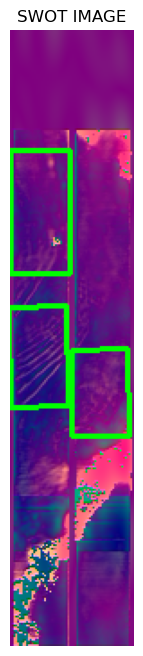

In [21]:
tif_files = list(DATA_DIR_OTHER.glob(f"images/{FILE_NAME}.tif"))

print(tif_files)

if len(tif_files) == 0:
    raise FileNotFoundError("No matching TIFF found")

tif_file = tif_files[0]

with rasterio.open(tif_file) as src:
    rgb = src.read([1, 2, 3])  # R,G,B

# Convert from (bands, rows, cols) -> (rows, cols, bands)
rgb = np.moveaxis(rgb, 0, -1)

plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.title("SWOT IMAGE")
plt.axis("off")
plt.show()

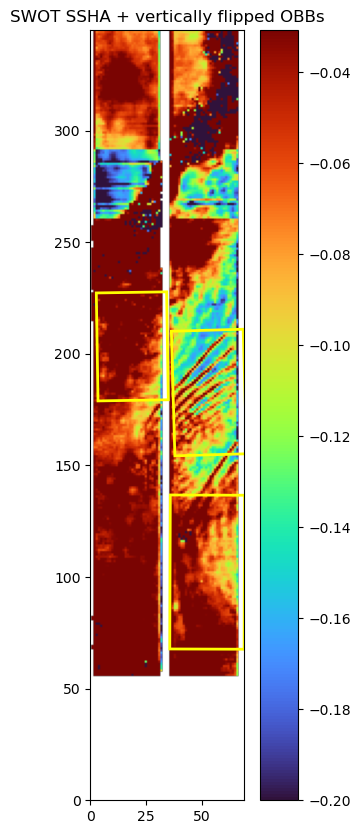

In [25]:
# -----------------------------
# Load OBBs (normalized)
# -----------------------------
def load_obb(file_path):
    boxes = []
    with open(file_path, "r") as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            coords = np.array(parts[1:]).reshape(4, 2)
            boxes.append(coords)
    return boxes

boxes = load_obb(obb_label[0])

# -----------------------------
# Image
# -----------------------------
ssha = ds_xy.ssha.values   # NO flip
ny, nx = ssha.shape

vmin, vmax = np.nanpercentile(ssha, [2.5, PERCENTAILE])

# -----------------------------
# Convert boxes → pixel space
# -----------------------------
def denormalize(coords, nx, ny):
    out = coords.copy()
    out[:, 0] *= nx
    out[:, 1] *= ny
    return out

# -----------------------------
# ROTATE BOXES
# -----------------------------
def rotate_boxes_180(coords, nx, ny):
    coords = coords.copy()
    coords[:, 0] = nx - coords[:, 0]   # horizontal flip
    #coords[:, 1] = ny - coords[:, 1]   # vertical flip
    return coords

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4, 10))

im = ax.imshow(
    ssha,
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    origin="lower",
    aspect="equal"
)

# -----------------------------
# Draw flipped boxes
# -----------------------------
for coords in boxes:
    coords_px = denormalize(coords, nx, ny)
    coords_px = rotate_boxes_180(coords_px, nx, ny)

    ax.add_patch(
        Polygon(
            coords_px,
            closed=True,
            edgecolor="yellow",
            facecolor="none",
            linewidth=2
        )
    )

ax.set_xlim(0, nx)
ax.set_ylim(0, ny)

ax.set_title("SWOT SSHA + vertically flipped OBBs")
plt.colorbar(im, ax=ax)
plt.show()

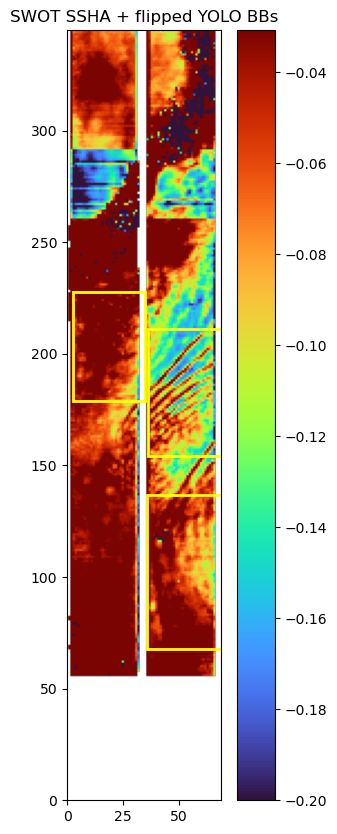

In [26]:
# -----------------------------
# Load YOLO BB labels
# -----------------------------
def load_yolo_bb(file_path):
    boxes = []
    with open(file_path, "r") as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            cls, xc, yc, w, h = parts
            boxes.append((cls, xc, yc, w, h))
    return boxes

boxes = load_yolo_bb(bb_label[0])

# -----------------------------
# Image
# -----------------------------
ssha = ds_xy.ssha.values
ny, nx = ssha.shape

vmin, vmax = np.nanpercentile(ssha, [2.5, PERCENTAILE])

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4, 10))

ax.imshow(
    ssha,
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    origin="lower",
    aspect="equal"
)

# -----------------------------
# Draw flipped YOLO boxes
# -----------------------------
for cls, xc, yc, w, h in boxes:

    # ✔️ FLIP Y FIRST (normalized space)
    # yc = 1.0 - yc
    xc = 1.0 - xc

    # convert to pixel space
    xc *= nx
    yc *= ny
    w *= nx
    h *= ny

    xmin = xc - w / 2
    ymin = yc - h / 2

    rect = Rectangle(
        (xmin, ymin),
        w,
        h,
        edgecolor="yellow",
        facecolor="none",
        linewidth=2
    )
    ax.add_patch(rect)

ax.set_xlim(0, nx)
ax.set_ylim(0, ny)

ax.set_title("SWOT SSHA + flipped YOLO BBs")
plt.colorbar(ax.images[0], ax=ax)
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import pywt

# -----------------------------
# Load OBBs (normalized)
# -----------------------------
def load_obb(file_path):
    boxes = []
    with open(file_path, "r") as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            coords = np.array(parts[1:]).reshape(4, 2)
            boxes.append(coords)
    return boxes

boxes = load_obb(obb_label[0])

# -----------------------------
# Image
# -----------------------------
ssha = ds_xy.ssha.values
ny, nx = ssha.shape

# Fill NaNs for filtering only
ssha_fill = np.nan_to_num(ssha, nan=np.nanmedian(ssha))

# -----------------------------
# FFT high-pass enhancement
# -----------------------------
def fft_highpass(img, radius_frac=0.04):
    h, w = img.shape

    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    y, x = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2
    radius = radius_frac * min(h, w)

    mask = np.sqrt((x - cx) ** 2 + (y - cy) ** 2) > radius

    filtered = fshift * mask
    out = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.real(out)

fft_img = fft_highpass(ssha_fill)

# -----------------------------
# DWT detail enhancement
# -----------------------------
def dwt_detail(img, wavelet="db2", level=2):
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)

    # Remove approximation, keep details
    coeffs_detail = [np.zeros_like(coeffs[0])]
    coeffs_detail.extend(coeffs[1:])

    detail = pywt.waverec2(coeffs_detail, wavelet=wavelet)
    return detail[:img.shape[0], :img.shape[1]]

dwt_img = dwt_detail(ssha_fill)

# -----------------------------
# Normalize for RGB composite
# -----------------------------
def normalize01(img, p_low=2, p_high=98):
    lo, hi = np.nanpercentile(img, [p_low, p_high])
    out = (img - lo) / (hi - lo)
    return np.clip(out, 0, 1)

ssha_norm = normalize01(ssha_fill)
fft_norm = normalize01(fft_img)
dwt_norm = normalize01(dwt_img)

rgb = np.dstack([
    ssha_norm,   # red: original SSHA
    fft_norm,    # green: FFT enhanced
    dwt_norm     # blue: DWT enhanced
])

# -----------------------------
# Convert boxes → pixel space
# -----------------------------
def denormalize(coords, nx, ny):
    out = coords.copy()
    out[:, 0] *= nx
    out[:, 1] *= ny
    return out

# -----------------------------
# FLIP BOXES ONLY
# -----------------------------
def flip_boxes_horizontal(coords, nx):
    coords = coords.copy()
    coords[:, 0] = nx - coords[:, 0]
    return coords

# -----------------------------
# Plot helper
# -----------------------------
def draw_boxes(ax, boxes, nx, ny):
    for coords in boxes:
        coords_px = denormalize(coords, nx, ny)
        coords_px = flip_boxes_horizontal(coords_px, nx)

        ax.add_patch(
            Polygon(
                coords_px,
                closed=True,
                edgecolor="yellow",
                facecolor="none",
                linewidth=2
            )
        )

    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)

# -----------------------------
# Plot original + enhanced views
# -----------------------------
vmin, vmax = np.nanpercentile(ssha, [2.5, PERCENTAILE])

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 10),
    dpi=600
)

# Original SSHA
im0 = axes[0].imshow(
    ssha,
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    origin="lower",
    aspect="equal"
)
draw_boxes(axes[0], boxes, nx, ny)
axes[0].set_title("Original SSHA")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# FFT
im1 = axes[1].imshow(
    fft_img,
    cmap=CMAP,
    origin="lower",
    aspect="equal"
)
draw_boxes(axes[1], boxes, nx, ny)
axes[1].set_title("FFT high-pass enhanced")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# DWT
im2 = axes[2].imshow(
    dwt_img,
    cmap=CMAP,
    origin="lower",
    aspect="equal"
)
draw_boxes(axes[2], boxes, nx, ny)
axes[2].set_title("DWT detail enhanced")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

# RGB composite
axes[3].imshow(
    rgb,
    origin="lower",
    aspect="equal"
)
draw_boxes(axes[3], boxes, nx, ny)
axes[3].set_title("3-channel SSHA + FFT + DWT")

for ax in axes:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")

plt.tight_layout()
plt.show()